In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [1]:
with open('/Users/cullen/Desktop/DTSC691_AppliedDataScience&Analyti/Datasets/gastrointestinal+lesions+in+regular+colonoscopy/data.txt',
         encoding = 'utf-8') as file:
    my_data = file.read()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/cullen/Desktop/DTSC691_AppliedDataScience&Analyti/Datasets/gastrointestinal+lesions+in+regular+colonoscopy/data.txt'

In [90]:
# THE GROUND TRUTH DATASET

# imported csv from xlsx file– needs some work due to formating errors....
gt_raw = pd.read_csv('ground_truth.xlsx - Hoja1.csv', header = None)

gt_rows = gt_raw.iloc[3: -11, :].copy()

classification_col = list(range(1, 10))
df_class = gt_rows.iloc[:, classification_col].copy()

# columns are repreating horizontally for some reason– rather we want the dataframe to span downwards.
binary_cols = list(range(17, 24))
gt_binary = gt_rows.iloc[:, binary_cols].copy()

gt_clean = pd.concat([df_class.reset_index(drop = True), gt_binary.reset_index(drop = True)], axis = 1)

new_names = [
    'LESION_ID', 'GROUND TRUTH', 
    'EXPERT_1', 'EXPERT_2', 'EXPERT_3', 'EXPERT_4', 
    'BEGINNER_1', 'BEGINNER_2', 'BEGINNER_3',
    'BINARY_EXPERT_1', 'BINARY_EXPERT_2', 'BINARY_EXPERT_3', 'BINARY_EXPERT_4', 
    'BINARY_BEGINNER_1', 'BINARY_BEGINNER_2', 'BINARY_BEGINNER_3'
]

gt_clean.columns = new_names

gt_clean.rename(columns = {'LESION_ID': 'Lesion_ID'}, inplace = True)
gt_clean.rename(columns = {'GROUND TRUTH': 'ground_truth'}, inplace = True)
gt_clean

,Lesion_ID,ground_truth,EXPERT_1,EXPERT_2,EXPERT_3,EXPERT_4,BEGINNER_1,BEGINNER_2,BEGINNER_3,BINARY_EXPERT_1,BINARY_EXPERT_2,BINARY_EXPERT_3,BINARY_EXPERT_4,BINARY_BEGINNER_1,BINARY_BEGINNER_2,BINARY_BEGINNER_3
0,serrated_8,serrated,serrated,adenoma,serrated,adenoma,serrated,adenoma,adenoma,resection,resection,resection,resection,resection,resection,resection
1,adenoma_2,adenoma,hyperplasic,serrated,hyperplasic,hyperplasic,serrated,serrated,serrated,no-resection,resection,no-resection,no-resection,resection,resection,resection
2,adenoma_3,adenoma,adenoma,adenoma,adenoma,adenoma,adenoma,adenoma,adenoma,resection,resection,resection,resection,resection,resection,resection
3,adenoma_4,adenoma,adenoma,adenoma,adenoma,adenoma,adenoma,adenoma,adenoma,resection,resection,resection,resection,resection,resection,resection
4,adenoma_5,adenoma,hyperplasic,hyperplasic,hyperplasic,hyperplasic,hyperplasic,adenoma,serrated,no-resection,no-resection,no-resection,no-resection,no-resection,resection,resection
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,serrated_15,serrated,adenoma,serrated,serrated,serrated,adenoma,serrated,adenoma,resection,resection,resection,resection,resection,resection,resection
72,adenoma_37,adenoma,adenoma,adenoma,adenoma,adenoma,adenoma,adenoma,adenoma,resection,resection,resection,resection,resection,resection,resection
73,adenoma_38,adenoma,adenoma,adenoma,adenoma,hyperplasic,adenoma,adenoma,serrated,resection,resection,resection,no-resection,resection,resection,resection
74,adenoma_39,adenoma,adenoma,adenoma,adenoma,hyperplasic,adenoma,adenoma,hyperplasic,resection,resection,resection,no-resection,resection,resection,no-resection


In [92]:
gt_clean.to_csv(
    "/Users/cullen/Desktop/DTSC691_AppliedDataScience&Analyti/FinalDataFrames/gt_clean.csv",
    index = False,
    na_rep = ''
)

In [106]:
lesion_id = gt_clean[['Lesion_ID', 'ground_truth']].drop_duplicates()
lesion_id.to_csv(
    "/Users/cullen/Desktop/DTSC691_AppliedDataScience&Analyti/FinalDataFrames/lesion_id.csv",
    index = False,
    na_rep = ''
)
lesion_id

,Lesion_ID,ground_truth
0,serrated_8,serrated
1,adenoma_2,adenoma
2,adenoma_3,adenoma
3,adenoma_4,adenoma
4,adenoma_5,adenoma
...,...,...
71,serrated_15,serrated
72,adenoma_37,adenoma
73,adenoma_38,adenoma
74,adenoma_39,adenoma


In [5]:
# the DATA dataset which corresponds with ground_truth. *NOTE* numeric_value likely is some sort of probability score; 
# might not be super relevant to what we're doing here, unless it can be used to predict accuracy....

import io

raw_columns = my_data.split('\n')

df_final = pd.DataFrame(raw_columns).iloc[:, 0].str.split(',', expand = True).T
df_final = df_final.iloc[:, :4]

df_final.columns = ['Lesion_ID', 'Type', 'Quality_Metric', 'Numeric_Value']
df_final['Type'] = pd.to_numeric(df_final['Type'], errors = 'coerce', downcast = 'integer')
df_final['Quality_Metric'] = pd.to_numeric(df_final['Quality_Metric'], errors = 'coerce', downcast = 'integer')
df_final['Numeric_Value'] = pd.to_numeric(df_final['Numeric_Value'], errors = 'coerce', downcast = 'integer')

df_final = df_final.dropna(subset = ['Numeric_Value'])

lesion_map = {1: 'Hyperplastic', 2: 'Serrated', 3: 'Adenoma'}
# BENIGN. A hyperplastic polyp is a non-cancerous (benign) growth that forms on the lining of the colon or stomach. 
# MALIGNANT. Serrated a precancerous type that are often flat and difficult to see during a colonoscopy. They are a significant precursor to a specific type of colon cancer. 
# MALIGNANT. Adenomatous polyps are non-cancerous growths that develop in the lining of the colon or rectum. They are considered precancerous lesions, meaning they have the potential to develop into cancer if left untreated. 

df_final['Lesion_Type'] = df_final['Type'].map(lesion_map)

df_final

,Lesion_ID,Type,Quality_Metric,Numeric_Value,Lesion_Type
0,adenoma_1,3,1,138.120,Adenoma
1,adenoma_1,3,2,127.990,Adenoma
2,adenoma_8,3,2,80.415,Adenoma
3,adenoma_8,3,1,90.896,Adenoma
4,adenoma_9,3,2,106.160,Adenoma
...,...,...,...,...,...
147,serrated_7,2,2,136.550,Serrated
148,serrated_8,2,2,96.852,Serrated
149,serrated_8,2,1,157.810,Serrated
150,serrated_9,2,1,93.569,Serrated


In [6]:
#after importing into pgadmin its been realized that there are duplicates
df_final.duplicated(subset = ['Lesion_ID'])

#lets rid the dataframe of duplicates 
df_final = df_final.drop_duplicates(subset = ['Lesion_ID'], keep = 'first')
df_final

,Lesion_ID,Type,Quality_Metric,Numeric_Value,Lesion_Type
0,adenoma_1,3,1,138.120,Adenoma
2,adenoma_8,3,2,80.415,Adenoma
4,adenoma_9,3,2,106.160,Adenoma
6,adenoma_10,3,1,148.730,Adenoma
8,adenoma_11,3,2,109.130,Adenoma
...,...,...,...,...,...
142,serrated_5,2,1,114.590,Serrated
144,serrated_6,2,1,163.680,Serrated
146,serrated_7,2,1,180.110,Serrated
148,serrated_8,2,2,96.852,Serrated


In [7]:
df_final.to_csv(
    "/Users/cullen/Desktop/DTSC691_AppliedDataScience&Analyti/FinalDataFrames/df_final.csv",
    index = False,
    na_rep = ''
)

In [8]:
# lesions with the lowest Type code are associated with slightly higher numeric feature values. These are usually
# resected. perhaps a high numeric_value can suggest need for resection. 

corr_TypeQualityNumeric = df_final[['Type', 'Quality_Metric', 'Numeric_Value']]
corr3 = corr_TypeQualityNumeric.corr(method = 'spearman')

print(corr3, df_final['Type'].value_counts())
df_final['Numeric_Value'].describe()

                    Type  Quality_Metric  Numeric_Value
Type            1.000000       -0.020732      -0.276132
Quality_Metric -0.020732        1.000000      -0.169534
Numeric_Value  -0.276132       -0.169534       1.000000 Type
3    40
1    21
2    15
Name: count, dtype: int64


count     76.000000
mean     129.642829
std       26.571689
min       65.564000
25%      112.460000
50%      129.845000
75%      150.552500
max      185.870000
Name: Numeric_Value, dtype: float64

In [9]:
# the LESION_INFO dataset; histology_class key – AD = adenoma; HP = hyperplastic; NO POLYP ; 
# SSL = sessile; TSA = traditional serrated adenoma; Other

lesion = pd.read_csv('/Users/cullen/Desktop/DTSC691_AppliedDataScience&Analyti/DataExploration/lesion_info.csv')

lesion

,unique_object_id,unique_video_name,size [mm],site,histology_extended,histology_class
0,001-001_1,001-001,5,ascending,adenoma,AD
1,001-001_2,001-001,5,transverse,adenoma,AD
2,001-001_3,001-001,4,descending,adenoma,AD
3,001-003_2,001-003,2,ascending,adenoma,AD
4,001-003_1,001-003,3,descending,adenoma,AD
...,...,...,...,...,...,...
127,004-014_3,004-014,6,ascending,adenoma LSTNG,AD
128,004-014_4,004-014,4,sigma,adenoma,AD
129,004-015_1,004-015,6,sigma,adenoma,AD
130,004-015_2,004-015,4,splenic_flexure,adenoma,AD


In [10]:
# location has a moderately significant relationship to type of disease, 
# and size has a weak relationship to both sit and histology. 
from sklearn.preprocessing import LabelEncoder

lesion2 = lesion.copy()
lesion2['site'].unique()

le = LabelEncoder()
lesion2['size [mm]q'] = le.fit_transform(lesion2['size [mm]'])
lesion2['site_encoded'] = le.fit_transform(lesion2['site'])
lesion2['histology_encoded'] = le.fit_transform(lesion2['histology_extended'])

lesion_matrix = lesion2[['size [mm]', 'site_encoded', 'histology_encoded']].corr()

lesion_matrix

,size [mm],site_encoded,histology_encoded
size [mm],1.000000,0.108798,0.14253
site_encoded,0.108798,1.000000,-0.04547
histology_encoded,0.142530,-0.045470,1.00000


<Axes: >

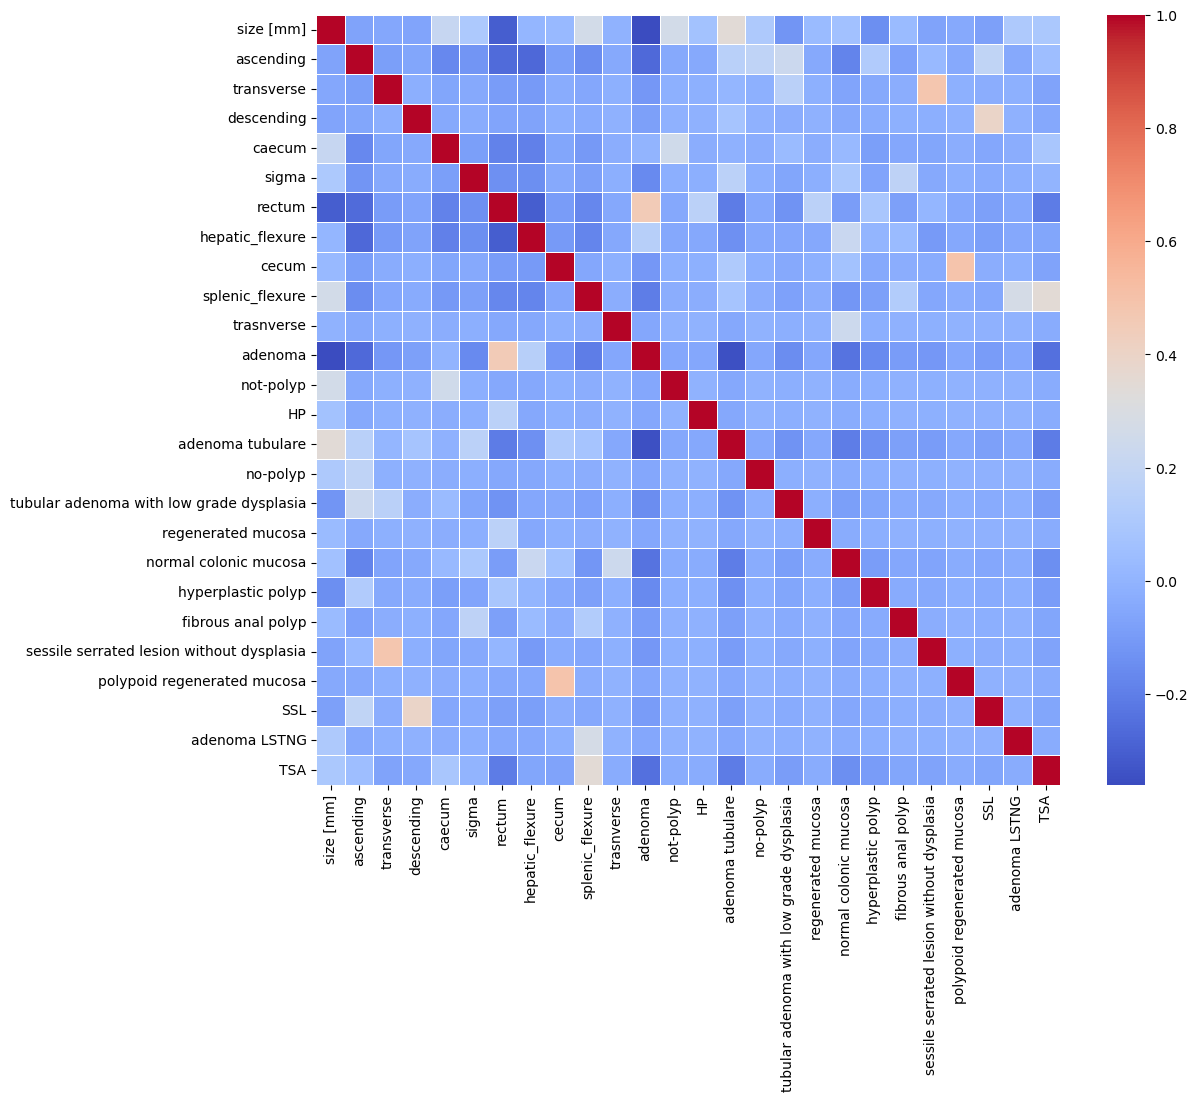

In [11]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

OHE = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore')
lesion3 = lesion.copy()

lesion3['site_encoded'] = le.fit_transform(lesion3['site'])
lesion3['histology_encoded'] = le.fit_transform(lesion3['histology_extended'])

data_to_encode = lesion3[['site_encoded', 'histology_encoded']]

lesion_OHE = OHE.fit_transform(data_to_encode)

feature = OHE.get_feature_names_out(data_to_encode.columns)
lesion_encoded_df = pd.DataFrame(lesion_OHE, columns = feature)

lesion3 = pd.concat(
    [lesion3.drop(columns = ['site_encoded', 'histology_encoded']), lesion_encoded_df], axis = 1
)

feature_names = [
    'unique_object_id', 'unique_video_name', 'size [mm]', 'site', 'histology_extended', 'histology_class', 
        'ascending', 'transverse', 'descending', 'caecum', 'sigma',
       'rectum', 'hepatic_flexure', 'cecum', 'splenic_flexure',
       'trasnverse',
        'adenoma', 'not-polyp', 'HP', 'adenoma tubulare', 'no-polyp',
       'tubular adenoma with low grade dysplasia', 'regenerated mucosa',
       'normal colonic mucosa', 'hyperplastic polyp',
       'fibrous anal polyp', 'sessile serrated lesion without dysplasia',
       'polypoid regenerated mucosa', 'SSL', 'adenoma LSTNG', 'TSA'
]
lesion3.columns = feature_names

numeric_lesion = lesion3.select_dtypes(include = np.number)
lesion_matrix = numeric_lesion.corr()

plt.figure(figsize = (12, 10))
sns.heatmap(
    lesion_matrix,
    annot = False, 
    cmap = 'coolwarm',
    fmt = '.2f',
    linewidth = .5
)

In [12]:
CRC_IBS = pd.read_csv('/Users/cullen/Desktop/DTSC691_AppliedDataScience&Analyti/DataExploration/CRC_Among_IBS - Sheet1.csv', header = None)

CRC_clean = CRC_IBS.iloc[1:]
new_names = [
    'Crohn’s disease',	'CRC',	'Non-CRC', 'p-value'
]
CRC_clean.columns = new_names

# CRC is now CRC_clean

In [13]:
# the CRC (colorectal cancer) table describe cormobidities, extraintestinal manifestation and 
# complications of Crohn’s disease patients.

regex_pattern = r'(\d+)\s*\(([\d\.]+)\)'

CRC_clean[['CRC_count', 'CRC_percentage']] = (
    CRC_clean['CRC']
    .str.extract(regex_pattern)
    .astype({0: 'float', 1: 'float'})
)

CRC_clean[['Non-CRC_count', 'Non-CRC_percentage']] = (
    CRC_clean['Non-CRC']
    .str.extract(regex_pattern)
    .astype({0: 'float', 1: 'float'})
)

CRC_clean = CRC_clean.drop(columns = ['CRC', 'Non-CRC'])
CRC_clean2 = CRC_clean.copy()
CRC_clean

/var/folders/16/_ybz_b2s3tl19p2thyvv7lzc0000gn/T/ipykernel_91916/3644370758.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CRC_clean[['CRC_count', 'CRC_percentage']] = (
/var/folders/16/_ybz_b2s3tl19p2thyvv7lzc0000gn/T/ipykernel_91916/3644370758.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CRC_clean[['CRC_count', 'CRC_percentage']] = (
/var/folders/16/_ybz_b2s3tl19p2thyvv7lzc0000gn/T/ipykernel_91916/3644370758.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from 

,Crohn’s disease,p-value,CRC_count,CRC_percentage,Non-CRC_count,Non-CRC_percentage
1,CIHD,<0.001,46.0,24.1,1739.0,13.7
2,CHF,<0.001,22.0,11.5,615.0,4.8
3,COPD,<0.001,33.0,17.3,1089.0,8.6
4,Asthma,0.383,26.0,13.6,2024.0,15.9
5,Chronic renal failure,<0.001,51.0,26.7,1220.0,9.6
6,Hypertension,<0.001,92.0,48.2,3440.0,27.1
7,Diabetes mellitus,<0.001,36.0,18.8,1116.0,8.8
8,Dyslipidemia,<0.001,93.0,48.7,3970.0,31.3
9,NAFLD,0.31,12.0,6.3,1057.0,8.3
10,Obesity,0.428,38.0,19.9,2831.0,22.3


In [110]:
#getting rid of the less than symbol in order for integration into sql
CRC_clean['p-value'] = CRC_clean['p-value'].str.replace('<', '')
CRC_clean

CRC_clean.to_csv(
    "/Users/cullen/Desktop/DTSC691_AppliedDataScience&Analyti/FinalDataFrames/CRC_clean.csv",
    index = False,
    na_rep = ''
)

In [14]:
# this heatmap is completely useless
''' 
numeric_CRRC = CRC_clean.select_dtypes(include = np.number)
CRC_matrix = numeric_CRRC.corr()

plt.figure(figsize = (12, 10))
sns.heatmap(
    CRC_matrix,
    annot = False, 
    cmap = 'coolwarm',
    fmt = '.2f',
    linewidth = .5
)
'''
CRC_clean[['CRC_count', 'Non-CRC_percentage']].corr()

,CRC_count,Non-CRC_percentage
CRC_count,1.000000,0.946152
Non-CRC_percentage,0.946152,1.000000


In [15]:
# *ASSUMING THERE IS NO RELATIONSHIP BETWEEN SAID COMORBILITY AND CRC* 
# if the odds ratio is greater than 1.0 then it is significant; if the lower confidence interval is greater
# than 1.0 then it is significant; if the p_value is lower than 0.05 then it is significant 

from scipy.stats.contingency import odds_ratio
from scipy.stats import fisher_exact

CRC_mod = CRC_clean.copy()
CRC_mod = CRC_mod[['Crohn’s disease', 'CRC_count', 'Non-CRC_count', 'p-value']]
#CRC_mod.drop(columns = ['CRC_count', 'Non-CRC_count'],inplace = True)
CRC_mod.columns = ['Comorbidity', 'N_CRC', 'N_nonCRC', 'p_value']

N_CRC = 191
N_nonCRC = 12697

results = []
for index, row in CRC_mod.dropna(subset = ['N_CRC', 'N_nonCRC']).iterrows():
    comorbidity_name = row['Comorbidity']
    a = int(row['N_CRC'])
    c = int(row['N_nonCRC'])
    b = N_CRC - a
    d = N_nonCRC - c

    contingency_table = np.array([[a, b], [c, d]])

    odds = odds_ratio(contingency_table, kind = 'sample')
    ci_low, ci_high = odds.confidence_interval()
    oddsr, p_value = fisher_exact(contingency_table)
    
    results.append({
        'Comorbidity': comorbidity_name,
        'Odds_ratio': odds.statistic,
        'CI_lower': ci_low,
        'CI_higher': ci_high,
        "Fisher's P_value": p_value
    })
df_results = pd.DataFrame(results)

df_results

,Comorbidity,Odds_ratio,CI_lower,CI_higher,Fisher's P_value
0,CIHD,1.999040,1.429270,2.795946,1.240739e-04
1,CHF,2.557406,1.628132,4.017073,2.479871e-04
2,COPD,2.226314,1.522131,3.256272,1.328184e-04
3,Asthma,0.830932,0.547997,1.259949,4.259516e-01
4,Chronic renal failure,3.426973,2.473724,4.747557,1.899521e-11
5,Hypertension,2.500716,1.877733,3.330390,7.733196e-10
6,Diabetes mellitus,2.410198,1.668501,3.481601,1.580365e-05
7,Dyslipidemia,2.086082,1.566877,2.777333,8.623741e-07
8,NAFLD,0.738255,0.410123,1.328919,3.562457e-01
9,Obesity,0.865552,0.605270,1.237764,4.833649e-01


In [58]:
#getting rid of the less than symbol in order for integration into sql
CRC_clean2['p-value'] = CRC_clean2['p-value'].str.replace('<', '')
CRC_clean2

CRC_clean2.to_csv(
    "/Users/cullen/Desktop/DTSC691_AppliedDataScience&Analyti/FinalDataFrames/CRC_clean2.csv",
    index = False,
    na_rep = ''
)

In [17]:
# the Supplmentary_material dataframe has to do with effectiveness of antibiotics in regards to diverticulitis. 
# the results of the study concluded that antibotic use reduces risk of intestinal resection and stoma creation.
# this study consisted of 131,936 admissions *this data can be used to discuss trends of tools used*

supp_table = pd.read_csv('/Users/cullen/Desktop/DTSC691_AppliedDataScience&Analyti/DataExploration/Supplementarymaterial.csv')

supp_table

,Characteristic,Non-Antibiotic Before (N),Antibiotic Before (N),P Value Before,Non-Antibiotic After (N),Antibiotic After (N),P Value After,Standardized Difference
0,Sex (male/female),3145/2916,70001/55874,<0.0001,3145/2916,3159/2902,0.81,0.0046
1,"Mean age (SD), years",65.8(18.1),52.5(17.5),<0.0001,65.8(18.1),65.4(18.0),0.27,0.0220
2,Age categories,NaN,NaN,<0.0001,NaN,NaN,1.00,NaN
3,≥80 years,1643,9892,NaN,1643,1638,NaN,0.0019
4,70−79 years,1342,14159,NaN,1342,1345,NaN,0.0012
5,60−69 years,1347,21293,NaN,1347,1355,NaN,0.0020
6,<60 years,1729,80531,NaN,1729,1723,NaN,0.0023
7,Race,NaN,NaN,<0.0001,NaN,NaN,1.00,NaN
8,White,5901,122865,NaN,5901,5909,NaN,0.0021
9,Black,155,2705,NaN,155,153,NaN,0.0076


In [18]:
supp_df = supp_table.copy()

#droping unnessesary columns for analysis and renaming remaining columns
supp_df.drop(columns = ['Non-Antibiotic After (N)', 'Antibiotic After (N)', 'P Value After', 'Standardized Difference'],inplace = True)
supp_df.columns = ['Characteristic', 'N_nonAntibiotic', 'N_Antibiotic', 'p_value']

#fixing rows with "/"
new_rows = pd.DataFrame({
    'Male' : [3145,	70001,	0.0001,	3145, 3159,	0.81, 0.0046], 
    'Female' : [2916, 55874, 0.0001, 2916, 2902, 0.81, 0.0046],
    'Academic_hospital' : [257, 6063, 0.039, 257, 259,	0.96, 0.0016],
    'nonAcademic_hospital' : [5804, 119812, 0.039, 5804, 5802, 0.96, 0.0016]
    })
supp_df = pd.concat([supp_df, new_rows], ignore_index = True)

#time to clean up mean age row
supp_df['N_nonAntibiotic'] = supp_df['N_nonAntibiotic'].astype(str).str.replace(r'\(.*?\)', '', regex = True)
supp_df['N_Antibiotic'] = supp_df['N_Antibiotic'].astype(str).str.replace(r'\(.*?\)', '', regex = True)
supp_df['N_nonAntibiotic'] = pd.to_numeric(supp_df['N_nonAntibiotic'], errors = 'coerce')
supp_df['N_Antibiotic'] = pd.to_numeric(supp_df['N_Antibiotic'], errors = 'coerce')

N_nonAntibiotic = 6061
N_Antibiotic = 125875

results = []
for index, row in supp_df.dropna(subset = ['N_Antibiotic', 'N_nonAntibiotic']).iterrows():
    characteristic_name = row['Characteristic']
    a = int(row['N_Antibiotic'])
    c = int(row['N_nonAntibiotic'])
    b = N_Antibiotic - a
    d = N_nonAntibiotic - c

    if any(x < 0 for x in [a, b, c, d]):
        continue

    contingency_table = np.array([[a, b], [c, d]])

    odds = odds_ratio(contingency_table, kind = 'sample')
    ci_low, ci_high = odds.confidence_interval()
    oddsr, p_value = fisher_exact(contingency_table)
    
    results.append({
        'Characteristic': characteristic_name,
        'Odds_ratio': odds.statistic,
        'CI_lower': ci_low,
        'CI_higher': ci_high,
        "Fisher's P_value": p_value
    })
df_results = pd.DataFrame(results)

df_results

,Characteristic,Odds_ratio,CI_lower,CI_higher,Fisher's P_value
0,"Mean age (SD), years",0.038123,0.026450,0.054949,4.368407e-55
1,≥80 years,0.229339,0.215931,0.243579,0.000000e+00
2,70−79 years,0.445671,0.418416,0.474702,2.287409e-121
3,60−69 years,0.712528,0.669478,0.758346,3.641565e-25
4,<60 years,4.449761,4.203515,4.710433,0.000000e+00
5,White,1.106767,0.942045,1.300290,2.130766e-01
6,Black,0.836805,0.710254,0.985903,3.761617e-02
7,Others,2.941913,1.215318,7.121469,9.021267e-03
8,Never/Unknown,1.286650,1.165416,1.420495,1.229377e-06
9,Current/Former,0.777212,0.703980,0.858062,1.229377e-06


In [72]:
supp_df['p_value'] = supp_df['p_value'].str.replace('<', '')
supp_df = supp_df.dropna(subset = ['Characteristic'])
supp_df.to_csv(
    "/Users/cullen/Desktop/DTSC691_AppliedDataScience&Analyti/FinalDataFrames/supp_df.csv",
    index = False,
    na_rep = ''
)

In [74]:
supp_df

,Characteristic,N_nonAntibiotic,N_Antibiotic,p_value,Male,Female,Academic_hospital,nonAcademic_hospital
0,Sex (male/female),NaN,NaN,0.0001,NaN,NaN,NaN,NaN
1,"Mean age (SD), years",65.8,52.5,0.0001,NaN,NaN,NaN,NaN
2,Age categories,NaN,NaN,0.0001,NaN,NaN,NaN,NaN
3,≥80 years,1643.0,9892.0,NaN,NaN,NaN,NaN,NaN
4,70−79 years,1342.0,14159.0,NaN,NaN,NaN,NaN,NaN
5,60−69 years,1347.0,21293.0,NaN,NaN,NaN,NaN,NaN
6,<60 years,1729.0,80531.0,NaN,NaN,NaN,NaN,NaN
7,Race,NaN,NaN,0.0001,NaN,NaN,NaN,NaN
8,White,5901.0,122865.0,NaN,NaN,NaN,NaN,NaN
9,Black,155.0,2705.0,NaN,NaN,NaN,NaN,NaN


In [20]:
# the ResearchData has to do with pts diagnosed with hemorrhoids and having them removed. 
# the study had do do with whatever medication they recieved for pain management and recovery time. 
# PS = post-op soreness; FSVP = first spontaneous voiding post-op; 
# FOC = first output colon;  MO = medication output; *Code might be pt_id?*

hemorrhoid = pd.read_csv('/Users/cullen/Desktop/DTSC691_AppliedDataScience&Analyti/DataExploration/Researchdata.csv')

hemorrhoid

,Sex,Age,BW/Ht,Code,MED,Operative time min,Hemorrhoid removed,PS 2,PS 6,PS 12,PS 24,FSVP,FOC,MO
0,Female,44,65/155,40,Xylocaine,30,2,6,4,4,3,2hr,No,No
1,Female,30,47/162,31,KY Jelly,15,1,1,3,6,5,9hr,No,9 hr
2,Female,51,45/145,5,KY Jelly,15,2,2,2,6,6,2hr,8hr,No
3,Male,54,80/175,1,KY Jelly,15,1,0,4,2,2,4hr,No,8hr
4,Male,52,53/167,24,Xylocaine,60,2,4,7,7,4,5hr,No,6hr
5,Male,71,60/165,21,Xylocaine,90,2,0,4,4,3,2hr,No,No
6,Male,52,73/168,30,Xylocaine,30,2,8,5,3,3,No,3hr,4hr
7,Female,60,55/145,37,Xylocaine,15,1,0,4,3,2,4hr,No,No
8,Female,44,56/154,11,Xylocaine,10,1,5,2,5,2,4hr,No,No
9,Female,27,60/167,38,Xylocaine,35,1,5,8,6,4,2hr,No,No


In [21]:
# index row 33 weight has 2 "//" in it
hemorrhoid['BW/Ht'].str.count('/').value_counts()

BW/Ht
1    38
2     1
Name: count, dtype: int64

In [22]:
hemorrhoid_mod = hemorrhoid.copy()

#converting "//" into "/" in order to seperate columns
hemorrhoid_mod['BW/Ht'] = hemorrhoid_mod['BW/Ht'].str.replace('//', '/', regex = False)
hemorrhoid_mod[['Body_Weight', 'Height']] = hemorrhoid_mod['BW/Ht'].str.split('/', expand = True)

#diving into 2 distinct columns (kg and cm)
hemorrhoid_mod['Body_Weight'] = pd.to_numeric(hemorrhoid_mod['Body_Weight'])
hemorrhoid_mod['Height'] = pd.to_numeric(hemorrhoid_mod['Height'])

#droping all irrelevant columns 
hemorrhoid_mod.drop(columns = ['BW/Ht', 'Code', 'MED', 'FSVP', 'FOC', 'MO'], inplace = True)

#change sex to binary for further analysis
sex_mapping = {'Male' : 1, 'Female' : 0}
hemorrhoid_mod['Sex'] = hemorrhoid_mod['Sex'].map(sex_mapping)

hemorrhoid_mod

,Sex,Age,Operative time min,Hemorrhoid removed,PS 2,PS 6,PS 12,PS 24,Body_Weight,Height
0,0,44,30,2,6,4,4,3,65,155
1,0,30,15,1,1,3,6,5,47,162
2,0,51,15,2,2,2,6,6,45,145
3,1,54,15,1,0,4,2,2,80,175
4,1,52,60,2,4,7,7,4,53,167
5,1,71,90,2,0,4,4,3,60,165
6,1,52,30,2,8,5,3,3,73,168
7,0,60,15,1,0,4,3,2,55,145
8,0,44,10,1,5,2,5,2,56,154
9,0,27,35,1,5,8,6,4,60,167


–––– Sex –––– 0.03370386570456685 –––– Age –––– -0.05881941323197076 –––– Body Weight –––– -0.006989361645661742 –––– Height –––– 0.17913136729697005 –––– Operative Time –––– 0.3008914762893773 –––– Statistics ––––              Sex        Age  Operative time min  Hemorrhoid removed  \
count  39.000000  39.000000           39.000000           39.000000   
mean    0.461538  51.717949           30.230769            1.589744   
std     0.505035  12.424400           17.751889            0.594623   
min     0.000000  23.000000            1.000000            1.000000   
25%     0.000000  44.500000           15.000000            1.000000   
50%     0.000000  54.000000           25.000000            2.000000   
75%     1.000000  60.000000           37.500000            2.000000   
max     1.000000  71.000000           90.000000            3.000000   

            PS 2       PS 6      PS 12      PS 24  Body_Weight      Height  
count  39.000000  39.000000  39.000000  39.000000    39.000000   39.

<Axes: >

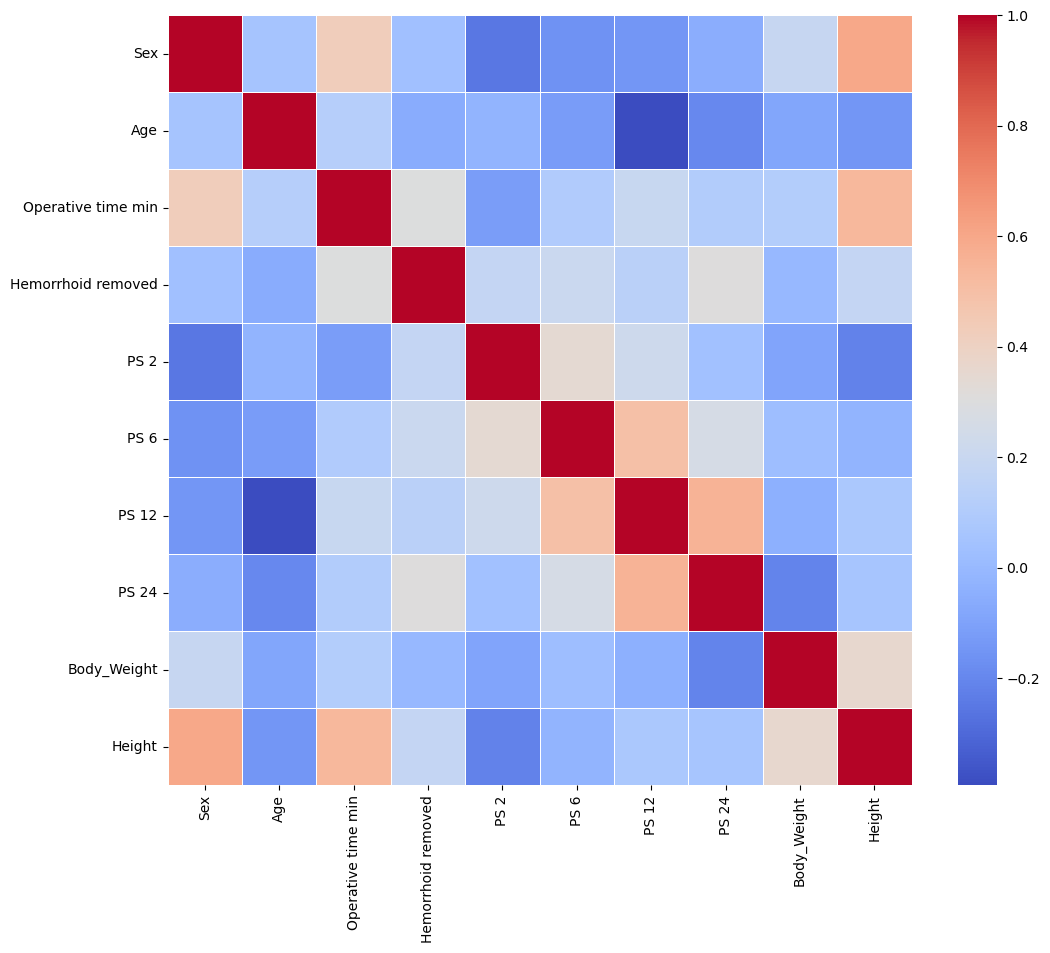

In [23]:
# in terms of p-value: age, height, and operative time might be relevant

print(
    "–––– Sex ––––",
    hemorrhoid_mod['Hemorrhoid removed'].corr(hemorrhoid_mod['Sex']), 
    "–––– Age ––––",
    hemorrhoid_mod['Hemorrhoid removed'].corr(hemorrhoid_mod['Age']), 
    "–––– Body Weight ––––",
    hemorrhoid_mod['Hemorrhoid removed'].corr(hemorrhoid_mod['Body_Weight']), 
    "–––– Height ––––",
    hemorrhoid_mod['Hemorrhoid removed'].corr(hemorrhoid_mod['Height']),
    "–––– Operative Time ––––",
    hemorrhoid_mod['Hemorrhoid removed'].corr(hemorrhoid_mod['Operative time min']),
    "–––– Statistics ––––",
    hemorrhoid_mod.describe())

corr_matrix = hemorrhoid_mod.corr()

plt.figure(figsize = (12, 10))
sns.heatmap(
    corr_matrix,
    annot = False, 
    cmap = 'coolwarm',
    fmt = '.2f',
    linewidth = .5
)

In [24]:
# lets try to figure out another odds ratio now that we have found some trends
Median_Age = hemorrhoid_mod['Age'].median()
Median_Height = hemorrhoid_mod['Operative time min'].median()

hemorrhoid_mod['High_Age'] = (hemorrhoid_mod['Age'] >= Median_Age).astype(int)
hemorrhoid_mod['Long_Time'] = (hemorrhoid_mod['Operative time min'] >= Median_Height).astype(int)

contingency_table = pd.crosstab(hemorrhoid_mod['High_Age'], hemorrhoid_mod['Long_Time'])

table_array = contingency_table.values

a, b = table_array[1, 1], table_array[1, 0]
c, d = table_array[0, 1], table_array[0, 0]

oddsr, p_value = fisher_exact(contingency_table)
OR = (a * b) / (d * c) if (b * c) != 0 else np.inf

#it seems that neither age nor opperating time are relevant
print("Contingency Table (High Age vs. Long Operative Time:")
print(contingency_table)

print("\n## Odds Ratio Analysis")
print(f"Fisher's Ratio: {OR:.2f}")
print(f"Fisher's P-Value: {p_value:.4f}")
print("OR > 1 menas patients with High Age (>= 54) have higher odds of Long Operative Time (>= 30 min)")

''' 
## Odds Ratio Utilizing MEAN values
Contingency Table (High Age vs. Long Operative Time:
Long_Time   0  1
High_Age        
0          11  4
1          16  8

## Odds Ratio Analysis
Fisher's Ratio: 2.91
Fisher's P-Value: 0.7342
OR > 1 menas patients with High Age (>= 54) have higher odds of Long Operative Time (>= 30 min)
'''

Contingency Table (High Age vs. Long Operative Time:
Long_Time  0   1
High_Age        
0          7  11
1          9  12

## Odds Ratio Analysis
Fisher's Ratio: 1.40
Fisher's P-Value: 1.0000
OR > 1 menas patients with High Age (>= 54) have higher odds of Long Operative Time (>= 30 min)


" \n## Odds Ratio Utilizing MEAN values\nContingency Table (High Age vs. Long Operative Time:\nLong_Time   0  1\nHigh_Age        \n0          11  4\n1          16  8\n\n## Odds Ratio Analysis\nFisher's Ratio: 2.91\nFisher's P-Value: 0.7342\nOR > 1 menas patients with High Age (>= 54) have higher odds of Long Operative Time (>= 30 min)\n"

In [25]:
# Demographic and clinical characteristics of right colon diverticulitis patients

RightC_Div = pd.read_csv('/Users/cullen/Desktop/DTSC691_AppliedDataScience&Analyti/DataExploration/RightColonDiv.csv')

RightC_Div

,Parameter,Sub-Category,N (Stage I),% (Stage I),Mean (Stage I),N (Stage II),% (Stage II),Mean (Stage II),Value,P,Test Note
0,Age (year),NaN,15,NaN,45.70,7,NaN,63.57,2.507,0.012,1.0
1,Gender,Male,10,66.7,NaN,3,42.9,NaN,1.068,0.376,2.0
2,Gender,Female,5,33.3,NaN,4,57.1,NaN,NaN,NaN,NaN
3,Fever(> 38.2 ºC),Yes,7,46.7,NaN,6,85.7,NaN,2.874,0.165,2.0
4,Fever(> 38.2 ºC),No,8,53.3,NaN,1,14.3,NaN,NaN,NaN,NaN
5,Nausea/vomiting,Yes,6,40.0,NaN,6,85.7,NaN,3.840,0.074,2.0
6,Nausea/vomiting,No,9,60.0,NaN,1,14.3,NaN,NaN,NaN,NaN
7,Diarrhea,Yes,3,20.0,NaN,5,71.4,NaN,5.207,0.052,2.0
8,Diarrhea,No,12,80.0,NaN,2,28.6,NaN,NaN,NaN,NaN
9,Bottom right Abdominal Pain,Yes,11,73.3,NaN,1,14.3,NaN,6.407,0.020,2.0


In [26]:
#unfortunately there was a 'yes' and a 'yes '
RightC_Div['Sub-Category'] = RightC_Div['Sub-Category'].str.strip()

In [27]:
Divertic = RightC_Div.copy()

#mapping binary findings
div_mapping = {'Male' : 1, 
               'Female' : 0,
              'Yes' : 1,
              'No' : 0}
Divertic['Sub-Category'] = Divertic['Sub-Category'].map(div_mapping)

#must convert everything to a float
Divertic['N (Stage I)'] = Divertic['N (Stage I)'].astype(float)
Divertic['N (Stage II)'] = Divertic['N (Stage II)'].astype(float)

#everything is clean now, time to run stats
cols = [
    'Sub-Category', 
    'N (Stage I)', 
    'N (Stage II)', 
    'Mean (Stage I)',
    'Mean (Stage II)',	
    'Value',
    'P'
]

for col in cols:
    Divertic[col] = pd.to_numeric(Divertic[col], errors = 'coerce')

divertic_numeric = Divertic[cols].copy()
corr_matrix = divertic_numeric.corr()

#unfortunately this isnt very insightful, but at least it seems like something is here!?
corr_matrix

,Sub-Category,N (Stage I),N (Stage II),Mean (Stage I),Mean (Stage II),Value,P
Sub-Category,1.000000,-0.223258,0.467099,NaN,NaN,NaN,NaN
N (Stage I),-0.223258,1.000000,0.111593,NaN,NaN,-0.611734,-0.172278
N (Stage II),0.467099,0.111593,1.000000,NaN,NaN,-0.405007,-0.380320
Mean (Stage I),NaN,NaN,NaN,1.000000,1.000000,-0.471018,0.497713
Mean (Stage II),NaN,NaN,NaN,1.000000,1.000000,-0.471418,0.498122
Value,NaN,-0.611734,-0.405007,-0.471018,-0.471418,1.000000,-0.466508
P,NaN,-0.172278,-0.380320,0.497713,0.498122,-0.466508,1.000000


In [28]:
from math import log, exp, sqrt

#correlation matrix was a bad idea, rather odds ratio is the only appropriate option
def odds_ratio_ci(a, b, c, d):
    OR = (a * d) / (b * c)
    se = sqrt(1/a + 1/b + 1/c + 1/d)

    #confidence interval of 95%
    z = 1.96
    L = exp(log(OR))
    U = exp(log(OR))
    
    return OR, L, U

#unfortunately we are lacking the standard deviation
def ttest_from_table(mean, n1, mean2, n2, sd1 = None, sd2 = None):
    if sd1 is None or sd2 is None:
        return None, None
        
    t, p = ttest_from_stats(
        mean1 = mean1, std1 = sd1, nobs1 = n1,
        mean2 = mean2, std2 = sd2, nobs2 = n2,
    )
    return t, p

reults = []

for i, row in Divertic.iterrows():
    param = row['Parameter']
    sub = row['Sub-Category']
    n1 = row['N (Stage I)']
    n2 = row['N (Stage II)']
    mean1 = row['Mean (Stage I)']
    mean2 = row['Mean (Stage II)']
    
    if pd.isna(sub):
        results.append({
            'Parameter': param,
            'Type': 'Continuous',
            'Test': 't-test', 
            'Stage I mean': mean1, 
            'Stage II mean': mean2,
            'P-value': row['P']
        })
        continue
        
    category = param
    group = Divertic[Divertic['Parameter'] == category]
    
    if len(group) == 2:
        r1 = group.iloc[0]
        r2 = group.iloc[1]
        
        a = r1['N (Stage II)']
        b = r1['N (Stage I)']
        c = r2['N (Stage II)']
        d = r2['N (Stage I)']
        
        a, b, c, d = int(a), int(b), int(c), int(d)
        
        OR, L, U = odds_ratio_ci(a, b, c, d)
        _, p_fisher = fisher_exact([[a, b], [c, d]])
                                   
        results.append({
            'Parameter': param,
            'Sub-Category comparison': f"{r1['Sub-Category']} vs {r2['Sub-Category']}",
            'Type': 'Categorical', 
            'Stage II (sub1)': a, 
            'Stage I (sub2)': b,
            'Stage II (sub1)': c, 
            'Stage I (sub2)': d,
            'Odds Ratio': OR,
            'CI 95% Lower': L,
            'CI 95% Upper': U,
            'Fisher P-value': p_fisher
        })

results_df = pd.DataFrame(results)

#stage 2 pts tend to be higher in age, have higher crp, higher leukocyte count, longer pain and more pain– compared to stage 1 pts
#significant p-values: bottom right abdominal pain, generalized pain– maybe diarrhea... but not really since its 0.052.
results_df

,Characteristic,Odds_ratio,CI_lower,CI_higher,Fisher's P_value,Parameter,Type,Test,Stage I mean,Stage II mean,P-value,Sub-Category comparison,Stage II (sub1),Stage I (sub2),Odds Ratio,CI 95% Lower,CI 95% Upper,Fisher P-value
0,"Mean age (SD), years",0.038123,0.026450,0.054949,4.368407e-55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,≥80 years,0.229339,0.215931,0.243579,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,70−79 years,0.445671,0.418416,0.474702,2.287409e-121,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,60−69 years,0.712528,0.669478,0.758346,3.641565e-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,<60 years,4.449761,4.203515,4.710433,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,White,1.106767,0.942045,1.300290,2.130766e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Black,0.836805,0.710254,0.985903,3.761617e-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Others,2.941913,1.215318,7.121469,9.021267e-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Never/Unknown,1.286650,1.165416,1.420495,1.229377e-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Current/Former,0.777212,0.703980,0.858062,1.229377e-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
